# Step 1–3 Evaluation — GPT-4o (t = 0)

Computes the score tables and per-conversation distribution plots for Steps 1.1, 1.2, 2 and 3.
The per-technique averages of these scores are the numbers reported in paper Tables 6–7
(Step 4 has its own notebook: `03`/`04_evaluation_step4_*`).

**Data sources.** Steps 1.1 / 1.2 read the merged CSVs produced by `pipeline/04`–`05`.
Steps 2–3 read the **raw outputs** (`results/gpt4o/raw/`, git-ignored) because they need the pipeline's
Step-1 best output (`*_final_results.json`) to define the evaluation scope — the participant set
P* and restaurant set R* carried forward by the Prompt Chaining. Without `raw/` those cells skip;
the shipped `Step2_Score.csv` / `Step3_Score.csv` were produced from the raw outputs.

Each score section is followed by a plot cell: per-conversation scores as jittered points +
box plots per technique — the per-conversation view behind the averages in the paper tables.

## Step 1.1 — Participant / Restaurant Lists and Chosen Restaurant

Set-based F1 (paper Eq. 1) for the participant and restaurant lists, plus exact match for the
chosen restaurant, per conversation × technique (averaged over 5 iterations)
→ `Step1_1_Score.csv`.

In [1]:
import pandas as pd
import numpy as np

# F1 computation function
def calculate_f1_list(gold_list, pred_list):
    if not gold_list and not pred_list:
        return 1.0
    if not gold_list or not pred_list:
        return 0.0
    gold_set = set(map(str.strip, gold_list))
    pred_set = set(map(str.strip, pred_list))
    tp = len(gold_set & pred_set)
    fp = len(pred_set - gold_set)
    fn = len(gold_set - pred_set)
    if tp == 0:
        return 0.0
    precision = tp / (tp + fp)
    recall = tp / (tp + fn)
    return 2 * (precision * recall) / (precision + recall)

# 1. Load CSV (adjust the path to your actual file location)
df = pd.read_csv('results/gpt4o/Step1_1_merged.csv', encoding='utf-8-sig')

# 2. Convert strings to lists
df['P_pred'] = df['participants'].fillna('').str.split('|')
df['P_gold'] = df['P_answer'].fillna('').str.split('|')
df['R_pred'] = df['restaurant_brands'].fillna('').str.split('|')
df['R_gold'] = df['R_answer'].fillna('').str.split('|')

# 3. Compute F1 and Binary Match
df['F1_participants'] = df.apply(lambda r: calculate_f1_list(r['P_gold'], r['P_pred']), axis=1)
df['F1_restaurants'] = df.apply(lambda r: calculate_f1_list(r['R_gold'], r['R_pred']), axis=1)
df['Final_match'] = np.where(
    df['final_restaurant'].fillna('').str.strip() == df['F_answer'].fillna('').str.strip(),
    1.0, 0.0
)

# 4. Compute per-conversation (iteration average)
conv_df = (
    df
    .groupby(['conversation_id','technique'])
    .agg({
        'F1_participants':'mean',
        'F1_restaurants':'mean',
        'Final_match':'mean'
    })
    .reset_index()
)

# 5. Per-technique Summary (mean, std)
summary = (
    conv_df
    .groupby('technique')
    .agg({
        'F1_participants':['mean','std'],
        'F1_restaurants':['mean','std'],
        'Final_match':['mean','std']
    })
)
# Flatten column names
summary.columns = ['_'.join(col) for col in summary.columns]
summary = summary.reset_index()

# 6. Combine Summary + individual rows to build Long format
records = []
metrics = {
    'F1_participants':'F1_Participants',
    'F1_restaurants':'F1_Restaurants',
    'Final_match':'Binary_Final Restaurant'
}
# Summary row
for metric_col, metric_name in metrics.items():
    for stat in ['mean','std']:
        for _, row in summary.iterrows():
            records.append({
                'Metric': metric_name,
                'Conversation_ID': 'Average' if stat=='mean' else 'Std',
                'Technique': row['technique'],
                'Value': round(row[f'{metric_col}_{stat}'], 3)
            })
# Individual conversation rows
for _, row in conv_df.iterrows():
    for metric_col, metric_name in metrics.items():
        records.append({
            'Metric': metric_name,
            'Conversation_ID': row['conversation_id'],
            'Technique': row['technique'],
            'Value': round(row[metric_col], 3)
        })

score_df = pd.DataFrame(records).pivot(index=['Metric','Conversation_ID'], columns='Technique', values='Value')

# Save CSV
score_df.to_csv('results/gpt4o/Step1_1_Score.csv', encoding='utf-8-sig')

# Display results
# import ace_tools as tools; tools.display_dataframe_to_user(name="Step1_Score Preview", dataframe=score_df)


Saved Step1_Binary_Final Restaurant_plot.png


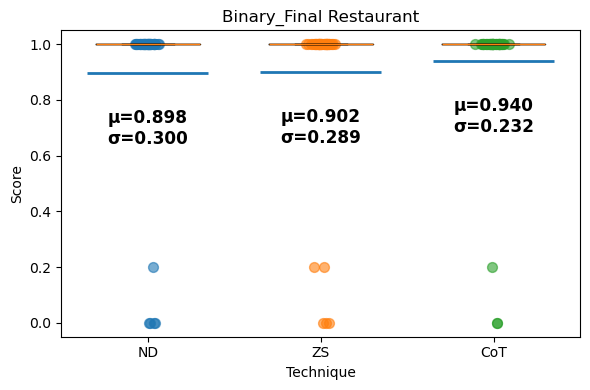

Saved Step1_F1_Participants_plot.png


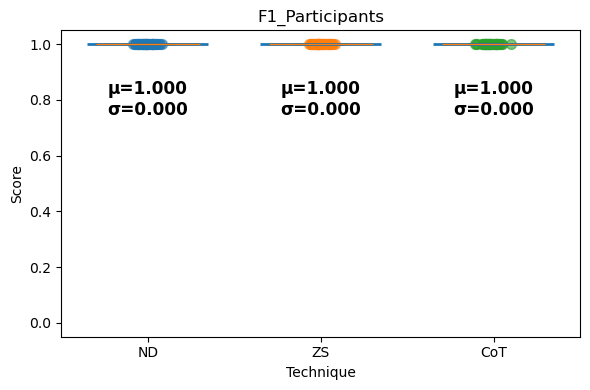

Saved Step1_F1_Restaurants_plot.png


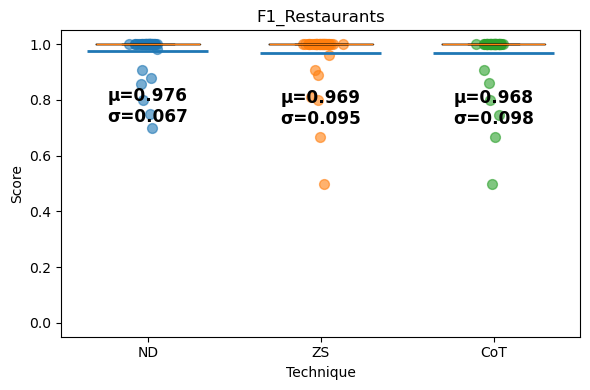

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- 1) Load restaurant-restricted evaluation results ---
result = pd.read_csv('results/gpt4o/Step1_1_Score.csv', encoding='utf-8-sig')

# --- 2) Convert pivot-form data into visualization form ---
# Separate by Metric
df1 = result[result['Metric'] == 'Binary_Final Restaurant'].drop(columns=['Metric'])
df2 = result[result['Metric'] == 'F1_Participants'].drop(columns=['Metric'])
df3 = result[result['Metric'] == 'F1_Restaurants'].drop(columns=['Metric'])

# Separate the Average and Std rows
df1_avg = df1[df1['Conversation_ID'] == 'Average'].iloc[0].drop('Conversation_ID').to_dict()
df1_std = df1[df1['Conversation_ID'] == 'Std'].iloc[0].drop('Conversation_ID').to_dict()
df2_avg = df2[df2['Conversation_ID'] == 'Average'].iloc[0].drop('Conversation_ID').to_dict()
df2_std = df2[df2['Conversation_ID'] == 'Std'].iloc[0].drop('Conversation_ID').to_dict()
df3_avg = df3[df3['Conversation_ID'] == 'Average'].iloc[0].drop('Conversation_ID').to_dict()
df3_std = df3[df3['Conversation_ID'] == 'Std'].iloc[0].drop('Conversation_ID').to_dict()

# Keep only per-conversation data
df1_data = df1[~df1['Conversation_ID'].isin(['Average', 'Std'])]
df2_data = df2[~df2['Conversation_ID'].isin(['Average', 'Std'])]
df3_data = df3[~df3['Conversation_ID'].isin(['Average', 'Std'])]

# --- 3) Visualization ---
techniques = ['ND', 'ZS', 'CoT']  # verify the technique list
metrics = {
    'Binary_Final Restaurant': {'data': df1_data, 'avg': df1_avg, 'std': df1_std},
    'F1_Participants': {'data': df2_data, 'avg': df2_avg, 'std': df2_std},
    'F1_Restaurants': {'data': df3_data, 'avg': df3_avg, 'std': df3_std},
}

for metric_name, metric_info in metrics.items():
    # Create a new figure for each metric
    plt.figure(figsize=(6, 4))
    
    # 1) scatter (point distribution)
    for i, tech in enumerate(techniques):
        if tech in metric_info['data'].columns:
            # Extract data for the current technique
            y = metric_info['data'][tech].dropna().values
            if len(y) == 0:  # skip if there is no data
                continue
            # Compute jitter
            x = np.random.normal(i, 0.04, size=len(y))
            # Draw points
            plt.scatter(x, y, alpha=0.6, s=50)
    
    # 2) boxplot
    boxplot_data = []
    valid_positions = []
    for i, tech in enumerate(techniques):
        if tech in metric_info['data'].columns:
            data = metric_info['data'][tech].dropna().values
            if len(data) > 0:
                boxplot_data.append(data)
                valid_positions.append(i)
    
    if boxplot_data:
        plt.boxplot(
            boxplot_data,
            positions=valid_positions,
            widths=0.6,
            showfliers=False,
            showcaps=True,
            whiskerprops={'linewidth': 1.5}
        )
    
    # 3) Show the mean line and μ,σ
    for i, tech in enumerate(techniques):
        if tech in metric_info['avg'] and tech in metric_info['std']:
            m = metric_info['avg'][tech]
            s = metric_info['std'][tech]

            if any(pos == i for pos in valid_positions):
                plt.hlines(m, i - 0.35, i + 0.35, linewidth=2)
                # Place μ,σ text below the mean line
                plt.text(
                    i,
                    m - 0.13,                     # place the y-coordinate below the mean
                    f"μ={m:.3f}\nσ={s:.3f}",
                    ha='center',
                    va='top',                      # so the text top aligns to the y-coordinate
                    fontsize=12.2,
                    weight='bold'
                )


    # 4) Configure axes and finalize
    plt.ylim(-0.05, 1.05)
    plt.xticks(range(len(techniques)), techniques)
    plt.title(f'{metric_name}')
    plt.xlabel('Technique')
    plt.ylabel('Score')
    plt.tight_layout()
    
    # Save the graph for the current metric - saved inside the loop
    filename = f'results/gpt4o/Step1_{metric_name}_plot.png'
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"Saved {filename}")
    
    plt.show()  # also display on screen

## Step 1.2 — Suggestion / Response Lists

F1 over (participant, label) pairs — a mislabeled participant counts against both precision and
recall (paper Eq. 1, Table 4) → `Step1_2_Score.csv`.

In [3]:
import os
import json
import pandas as pd

# --- 1) Load the source CSV ---
score2 = pd.read_csv('results/gpt4o/Step1_2_Suggestion.csv', encoding='utf-8-sig')
resp2 = pd.read_csv('results/gpt4o/Step1_2_Response.csv', encoding='utf-8-sig')

# --- 2) Define F1 computation functions ---
def f1_list(gold, pred):
    """Simple F1 computation for Step1.2 (no restaurant filtering)."""
    if not gold and not pred: 
        return 1.0
    if not gold or not pred: 
        return 0.0
    
    g, p = set(gold), set(pred)
    
    tp = len(g & p)
    fp = len(p - g)
    fn = len(g - p)
    
    if tp == 0: 
        return 0.0
    prec, rec = tp/(tp+fp), tp/(tp+fn)
    if prec + rec == 0: 
        return 0.0
    return 2*prec*rec/(prec+rec)

# --- 3) Aggregate F1 by conversation, technique, and iteration ---
records = []
for (conv, tech, it), grp in score2.groupby(['conversation_id', 'technique', 'iteration']):
    
    # Suggestion F1
    pred_s = (grp['participant'] + '|' + grp['suggestion']).tolist()
    gold_s = (grp['participant'] + '|' + grp['Answer']).tolist()
    f1_s = f1_list(gold_s, pred_s)
    
    # Response F1
    grp_r = resp2[
        (resp2['conversation_id']==conv) &
        (resp2['technique']==tech) &
        (resp2['iteration']==it)
    ]
    pred_r = (grp_r['participant'] + '|' + grp_r['response']).tolist()
    gold_r = (grp_r['participant'] + '|' + grp_r['Answer']).tolist()
    f1_r = f1_list(gold_r, pred_r)
    
    records.append({
        'conversation_id': conv,
        'technique': tech,
        'iteration': it,
        'F1_Suggestion': f1_s,
        'F1_Response': f1_r
    })

df = pd.DataFrame(records)

# --- 4) Compute per-conversation, per-technique averages ---
conv2 = (
    df
    .groupby(['conversation_id','technique'])[['F1_Suggestion','F1_Response']]
    .mean()
    .reset_index()
)

# --- 5) Per-Metric pivot + add-Average/Std function ---
def make_metric_table(metric):
    # Build pivot table
    pivot = conv2.pivot(index='conversation_id', columns='technique', values=metric)
    # Add Average, Std rows
    pivot.loc['Average'] = pivot.mean()
    pivot.loc['Std'] = pivot.std()
    # Index to column
    pivot = pivot.reset_index().rename(columns={'conversation_id':'Conversation_ID'})
    # Insert the Metric column at the front
    pivot.insert(0, 'Metric', metric)
    # Drop the column-name level
    pivot.columns.name = None
    return pivot

# --- 6) Build and combine tables for the two Metrics ---
table_s = make_metric_table('F1_Suggestion')
table_r = make_metric_table('F1_Response')
result = pd.concat([table_s, table_r], ignore_index=True)

# --- 7) Save to CSV ---
result.to_csv('results/gpt4o/Step1_2_Score.csv', index=False, encoding='utf-8-sig')
print("Saved → results/gpt4o/Step1_2_Score.csv")

Saved → _temp0.0/Step1_2_Score.csv


Saved Step1_F1_Suggestion_plot.png


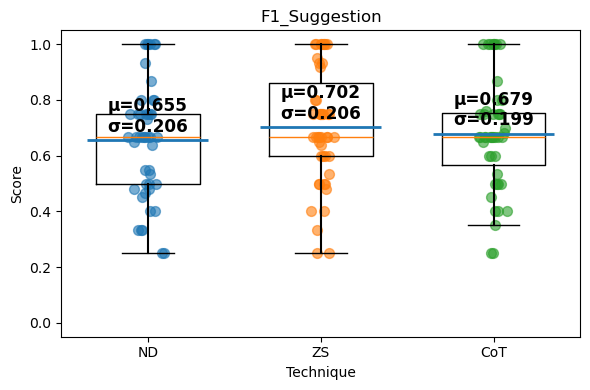

Saved Step1_F1_Response_plot.png


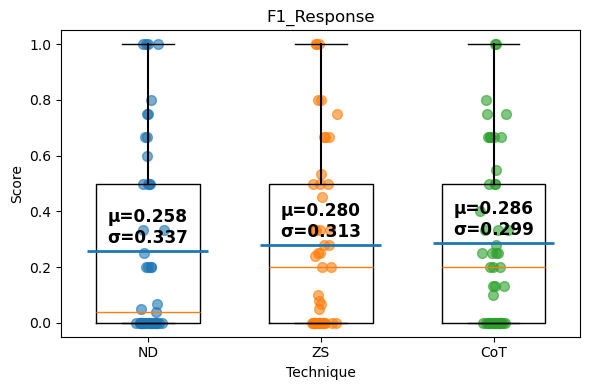

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- 1) Load restaurant-restricted evaluation results ---
result = pd.read_csv('results/gpt4o/Step1_2_Score.csv', encoding='utf-8-sig')

# --- 2) Convert pivot-form data into visualization form ---
# Separate by Metric
sugg_df = result[result['Metric'] == 'F1_Suggestion'].drop(columns=['Metric'])
resp_df = result[result['Metric'] == 'F1_Response'].drop(columns=['Metric'])

# Separate the Average and Std rows
sugg_avg = sugg_df[sugg_df['Conversation_ID'] == 'Average'].iloc[0].drop('Conversation_ID').to_dict()
sugg_std = sugg_df[sugg_df['Conversation_ID'] == 'Std'].iloc[0].drop('Conversation_ID').to_dict()
resp_avg = resp_df[resp_df['Conversation_ID'] == 'Average'].iloc[0].drop('Conversation_ID').to_dict()
resp_std = resp_df[resp_df['Conversation_ID'] == 'Std'].iloc[0].drop('Conversation_ID').to_dict()

# Keep only per-conversation data
sugg_data = sugg_df[~sugg_df['Conversation_ID'].isin(['Average', 'Std'])]
resp_data = resp_df[~resp_df['Conversation_ID'].isin(['Average', 'Std'])]

# --- 3) Visualization ---
techniques = ['ND', 'ZS', 'CoT']  # verify the technique list
metrics = {
    'F1_Suggestion': {'data': sugg_data, 'avg': sugg_avg, 'std': sugg_std},
    'F1_Response': {'data': resp_data, 'avg': resp_avg, 'std': resp_std}
}

for metric_name, metric_info in metrics.items():
    # Create a new figure for each metric
    plt.figure(figsize=(6, 4))
    
    # 1) scatter (point distribution)
    for i, tech in enumerate(techniques):
        if tech in metric_info['data'].columns:
            # Extract data for the current technique
            y = metric_info['data'][tech].dropna().values
            if len(y) == 0:  # skip if there is no data
                continue
            # Compute jitter
            x = np.random.normal(i, 0.04, size=len(y))
            # Draw points
            plt.scatter(x, y, alpha=0.6, s=50)
    
    # 2) boxplot
    boxplot_data = []
    valid_positions = []
    for i, tech in enumerate(techniques):
        if tech in metric_info['data'].columns:
            data = metric_info['data'][tech].dropna().values
            if len(data) > 0:
                boxplot_data.append(data)
                valid_positions.append(i)
    
    if boxplot_data:
        plt.boxplot(
            boxplot_data,
            positions=valid_positions,
            widths=0.6,
            showfliers=False,
            showcaps=True,
            whiskerprops={'linewidth': 1.5}
        )
    
    # 3) Show the mean line and μ,σ
    for i, tech in enumerate(techniques):
        if tech in metric_info['avg'] and tech in metric_info['std']:
            m = metric_info['avg'][tech]
            s = metric_info['std'][tech]
            
            # Plot only when data is available
            if any(pos == i for pos in valid_positions):
                plt.hlines(m, i - 0.35, i + 0.35, linewidth=2)
                plt.text(i, m + 0.015, f"μ={m:.3f}\nσ={s:.3f}",
                         ha='center', va='bottom', fontsize=12.2, weight='bold')
    
    # 4) Configure axes and finalize
    plt.ylim(-0.05, 1.05)
    plt.xticks(range(len(techniques)), techniques)
    plt.title(f'{metric_name}')
    plt.xlabel('Technique')
    plt.ylabel('Score')
    plt.tight_layout()
    
    # Save the graph for the current metric - saved inside the loop
    filename = f'results/gpt4o/Step1_{metric_name}_plot.png'
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"Saved {filename}")
    
    plt.show()  # also display on screen

## Step 2 — Mentioned Table

Paper metric (Table 7): set-based F1 over the (participant, restaurant) pairs labeled
`Mentioned`, scoped to the Step-1 best output. **Requires `raw/`** → `Step2_Score.csv`.

In [5]:
import os
import json
import pandas as pd

# ──────────────────────────────────────────────
# 1. Helper functions
# ──────────────────────────────────────────────
def normalize_name(x: str) -> str:
    """Strip whitespace + lowercase (restaurant-name standardization)."""
    return x.strip().lower()

def f1_score(tp: int, fp: int, fn: int) -> float:
    """F1 computation based on Precision and Recall (avoids zero denominator)."""
    if tp == 0:
        return 0.0
    prec = tp / (tp + fp) if tp + fp > 0 else 0.0
    rec  = tp / (tp + fn) if tp + fn > 0 else 0.0
    return 2 * prec * rec / (prec + rec) if prec + rec > 0 else 0.0

def score_table(gold, pred):
    """
    Paper metric (Eq. 1 / Table 7): set-based F1 over (participant, restaurant)
    pairs labeled 'Mentioned'. Both tables arrive pre-filtered to the
    evaluation scope.
    """
    def mentioned_pairs(table):
        return {(r["participant"], normalize_name(r["restaurant"]))
                for r in table
                if str(r.get("mention", "")).strip() == "Mentioned"}

    gp = mentioned_pairs(gold)
    pp = mentioned_pairs(pred)
    if not gp and not pp:
        return 1.0
    tp = len(gp & pp)
    return f1_score(tp, len(pp - gp), len(gp - pp))

# ──────────────────────────────────────────────
# 2. Directories and parameters
# ──────────────────────────────────────────────
results_dir = "results/gpt4o/raw"       # path to prediction JSON
gold_dir    = "data/gold"    # path to gold JSON

techniques  = ["CoT", "PD", "SR", "MoRE"]
iterations  = range(1, 6)

# ──────────────────────────────────────────────
# 3. Evaluation loop
# ──────────────────────────────────────────────
rows = []

for folder in os.listdir(results_dir):
    if not folder.endswith("_log"):
        continue
    conv_id     = folder.replace("_log", "")
    folder_path = os.path.join(results_dir, folder)

    # 3-1) Obtain the evaluation scope (participants, restaurants)
    final_path = os.path.join(folder_path, f"{folder}_final_results.json")
    with open(final_path, encoding="utf-8") as f:
        final_json = json.load(f)

    scope_participants = set(final_json["step1"]["participants"])
    scope_restaurants  = {normalize_name(r)
                          for r in final_json["step1"]["restaurant_brands"]}

    # 3-2) Load Gold and filter by scope
    gold_path = os.path.join(gold_dir, f"{conv_id}_log", "step2_gold.json")
    with open(gold_path, encoding="utf-8") as f:
        gold_table = json.load(f)["mentioned_table"]

    gold_filt = [g for g in gold_table
                 if g["participant"] in scope_participants
                 and normalize_name(g["restaurant"]) in scope_restaurants]

    # 3-3) Technique x iteration evaluation
    for tech in techniques:
        f1_list = []
        for it in iterations:
            pred_path = os.path.join(
                folder_path,
                f"{conv_id}_log_Step2_{tech}_{it}.json"
            )
            if not os.path.isfile(pred_path):
                continue
            with open(pred_path, encoding="utf-8") as f:
                pred_table = json.load(f)["Result"]["mentioned_table"]

            pred_filt = [p for p in pred_table
                         if p["participant"] in scope_participants
                         and normalize_name(p["restaurant"]) in scope_restaurants]

            f1_list.append(score_table(gold_filt, pred_filt))

        if f1_list:       # only when this technique has valid iterations
            rows.append({
                "conversation_id": conv_id,
                "technique": tech,
                "F1_Mentioned": sum(f1_list) / len(f1_list)
            })

# ──────────────────────────────────────────────
# 4. Aggregate and save
# ──────────────────────────────────────────────
df    = pd.DataFrame(rows)
pivot = df.pivot(index="conversation_id",
                 columns="technique",
                 values="F1_Mentioned")
pivot.loc["Average"] = pivot.mean()
pivot.loc["Std"]     = pivot.std()

pivot.to_csv("results/gpt4o/Step2_Score.csv", encoding="utf-8-sig")
print("Saved → results/gpt4o/Step2_Score.csv")


Saved → _temp0.0/Step2_Score.csv


Saved _temp0.0/Step2_F1_Mentioned_plot.png


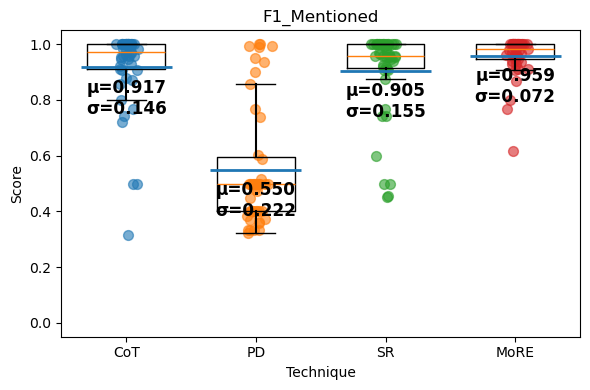

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np # add Numpy (for jitter computation)

# 1) Load and preprocess CSV (same as original code)
df = pd.read_csv('results/gpt4o/Step2_Score.csv', encoding='utf-8-sig', index_col=0)
df = df.reset_index().rename(columns={'index':'conversation_id'})

# Exclude the 'Average' and 'Std' rows
df = df[~df['conversation_id'].isin(['Average','Std'])]

# Convert from wide to long format
melt = df.melt(
    id_vars=['conversation_id'],
    value_vars=['CoT','PD','SR','MoRE'],
    var_name='technique',
    value_name='F1_Mentioned' # value_name is set to 'F1_Mentioned' here
)

# 2) Compute mean and std (same as original code)
summary = (
    melt
    .groupby('technique')['F1_Mentioned'] # use the value_name defined in melt
    .agg(['mean','std'])
    .reset_index()
)

# 3) Visualization settings (Seaborn style removed)
# sns.set(style='whitegrid') # removed
techniques = ['CoT','PD','SR','MoRE']
# palette = sns.color_palette('pastel', len(techniques)) # removed

# --- Start Matplotlib-based visualization ---
plt.figure(figsize=(6, 4)) # use plt to match the original style

# 4) scatter (point distribution, using plt.scatter and numpy jitter)
for i, tech in enumerate(techniques):
    # Use the correct column name ('F1_Mentioned') from the melted DataFrame and add dropna
    y = melt.loc[melt['technique'] == tech, 'F1_Mentioned'].dropna().values
    if len(y) == 0: # skip when there is no data
        continue
    # Compute jitter with Numpy
    x = np.random.normal(i, 0.04, size=len(y))
    # Use plt.scatter
    plt.scatter(
        x, y,
        alpha=0.6,
        s=50 # set point size to 50 (to match the original style)
        # Remove the color argument (use default color)
    )

# 5) boxplot (using plt.boxplot)
# Prepare boxplot data (including dropna)
boxplot_data = [melt.loc[melt['technique'] == tech, 'F1_Mentioned'].dropna().values for tech in techniques]
# Handle techniques with no data
valid_boxplot_data = [d for d in boxplot_data if len(d) > 0]
valid_positions = [i for i, d in enumerate(boxplot_data) if len(d) > 0]

# Use plt.boxplot when valid data is available
if valid_boxplot_data:
    plt.boxplot(
        valid_boxplot_data,
        positions=valid_positions,
        widths=0.6,
        showfliers=False, # do not show outliers
        showcaps=True,    # show whisker cap lines
        whiskerprops={'linewidth': 1.5} # whisker line width
        # Remove palette, boxprops, patch_artist, etc. (matplotlib default style)
    )

# 6) Add mean line and μ,σ text (default colors)
for i, tech in enumerate(techniques):
    # Check the summary data
    tech_summary = summary.loc[summary['technique'] == tech]
    if not tech_summary.empty:
        m = tech_summary['mean'].values[0]
        s = tech_summary['std'].values[0]
        # Plot only when this technique has data
        if len(boxplot_data[i]) > 0:
            # Use plt.hlines, remove the colors argument
            plt.hlines(m, i - 0.35, i + 0.35, linewidth=2)
            # Use plt.text, remove the color argument
            plt.text(
                i, m - 0.18,
                f'μ={m:.3f}\nσ={s:.3f}',
                ha='center', va='bottom',
                fontsize=12.2, weight='bold'
            )

# 7) Configure axes and finalize
plt.ylim(-0.05, 1.05)
plt.xticks(range(len(techniques)), techniques)
plt.title('F1_Mentioned')
plt.xlabel('Technique')
plt.ylabel('Score')
plt.tight_layout()

# Save first! (before show)
filename = 'results/gpt4o/Step2_F1_Mentioned_plot.png'  # set directly instead of metric_name
plt.savefig(filename, dpi=300, bbox_inches='tight')
print(f"Saved {filename}")

plt.show()  # show after saving


## Step 3 — Perception Table

Cell-level scoring of the perception labels within the Step-1 scope. **Requires `raw/`**
→ `Step3_Score.csv`.

In [7]:
import os
import json
import pandas as pd

# ──────────────────────────────────────────────
# 1. Helper functions
# ──────────────────────────────────────────────
def normalize_name(x: str) -> str:
    return x.strip().lower()

def f1_score(tp: int, fp: int, fn: int) -> float:
    if tp == 0:
        return 0.0
    prec = tp / (tp + fp) if tp + fp > 0 else 0.0
    rec  = tp / (tp + fn) if tp + fn > 0 else 0.0
    return 2 * prec * rec / (prec + rec) if prec + rec > 0 else 0.0

def score_table(gold, pred):
    """Both Gold and Pred already arrive filtered to the evaluation scope."""
    gold_map = {(g["participant"], normalize_name(g["restaurant"])): g
                for g in gold}
    pred_map = {(p["participant"], normalize_name(p["restaurant"])): p
                for p in pred}

    tp = fp = fn = 0

    # TP / FN
    for key, g in gold_map.items():
        if key in pred_map:
            if g["perception"].strip() == pred_map[key]["sentiment"].strip():
                tp += 1
            else:
                fn += 1
        else:
            fn += 1

    # FP (within evaluation scope but not in Gold)
    for key in pred_map:
        if key not in gold_map:
            fp += 1

    return f1_score(tp, fp, fn)

# ──────────────────────────────────────────────
# 2. Directories and parameters
# ──────────────────────────────────────────────
results_dir = "results/gpt4o/raw"        # Step3 predictions
gold_dir    = "data/gold"     # Gold answers

techniques  = ["CoT", "PD", "SR", "MoRE"]
iterations  = range(1, 6)

# ──────────────────────────────────────────────
# 3. Evaluation loop
# ──────────────────────────────────────────────
rows = []

for folder in os.listdir(results_dir):
    if not folder.endswith("_log"):
        continue
    conv_id     = folder.replace("_log", "")
    folder_path = os.path.join(results_dir, folder)

    # 3-1) Read the evaluation scope (participants, restaurants)
    final_path = os.path.join(folder_path, f"{folder}_final_results.json")
    with open(final_path, encoding="utf-8") as f:
        final_json = json.load(f)

    scope_participants = set(final_json["step1"]["participants"])
    scope_restaurants  = {normalize_name(r)
                          for r in final_json["step1"]["restaurant_brands"]}

    # 3-2) Load Gold and filter by scope
    gold_path = os.path.join(gold_dir, f"{conv_id}_log", "step3_gold.json")
    with open(gold_path, encoding="utf-8") as f:
        gold_table = json.load(f)["perception_table"]

    gold_filt = [g for g in gold_table
                 if g["participant"] in scope_participants
                 and normalize_name(g["restaurant"]) in scope_restaurants]

    # 3-3) Technique x iteration evaluation
    for tech in techniques:
        f1_list = []
        for it in iterations:
            pred_path = os.path.join(
                folder_path,
                f"{conv_id}_log_Step3_{tech}_{it}.json"
            )
            if not os.path.isfile(pred_path):
                continue
            with open(pred_path, encoding="utf-8") as f:
                pred_table = json.load(f)["Result"]["sentiment_table"]

            pred_filt = [p for p in pred_table
                         if p["participant"] in scope_participants
                         and normalize_name(p["restaurant"]) in scope_restaurants]

            f1_list.append(score_table(gold_filt, pred_filt))

        if f1_list:    # record only when valid iterations exist
            rows.append({
                "conversation_id": conv_id,
                "technique": tech,
                "F1_Sentiment": sum(f1_list) / len(f1_list)
            })

# ──────────────────────────────────────────────
# 4. Aggregate and save
# ──────────────────────────────────────────────
df    = pd.DataFrame(rows)
pivot = df.pivot(index="conversation_id",
                 columns="technique",
                 values="F1_Sentiment")
pivot.loc["Average"] = pivot.mean()
pivot.loc["Std"]     = pivot.std()

pivot.to_csv("results/gpt4o/Step3_Score.csv", encoding="utf-8-sig")
print("Saved → results/gpt4o/Step3_Score.csv")


Saved → _temp0.0/Step3_Score.csv


Saved _temp0.0/Step3_F1_Perception_plot.png


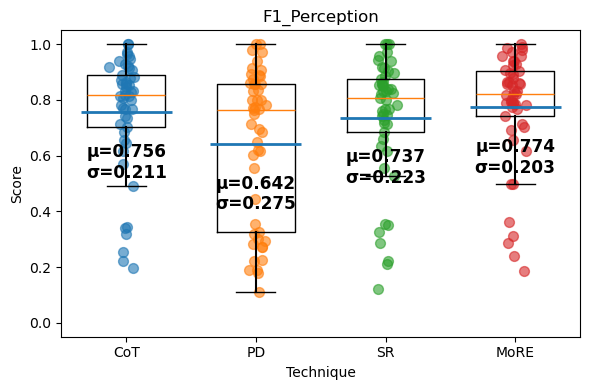

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1) Load the source CSV
df = pd.read_csv('results/gpt4o/Step3_Score.csv', encoding='utf-8-sig')
# If there is no conversation_id column, add/change it as needed

# 2) wide->long conversion
techniques = ['CoT','PD','SR','MoRE']
melt = df.melt(
    id_vars=['conversation_id'],
    value_vars=techniques,
    var_name='technique',
    value_name='F1_Perception'   # matching this avoids later errors
)

# 3) Statistical summary
summary = melt.groupby('technique')['F1_Perception']\
               .agg(['mean','std'])\
               .reset_index()

# 4) Visualize and save
plt.figure(figsize=(6, 4))
for i, tech in enumerate(techniques):
    y = melt.loc[melt['technique']==tech, 'F1_Perception'].dropna().values
    if not len(y): continue
    x = np.random.normal(i, 0.04, size=len(y))
    plt.scatter(x, y, alpha=0.6, s=50)

boxplot_data = [melt.loc[melt['technique']==tech, 'F1_Perception'].dropna().values for tech in techniques]
valid_data = [d for d in boxplot_data if len(d)]
valid_pos  = [i for i,d in enumerate(boxplot_data) if len(d)]
if valid_data:
    plt.boxplot(valid_data, positions=valid_pos, widths=0.6, showfliers=False, showcaps=True, whiskerprops={'linewidth':1.5})

for i, tech in enumerate(techniques):
    m = summary.loc[summary['technique']==tech, 'mean'].values[0]
    s = summary.loc[summary['technique']==tech, 'std'].values[0]
    if i in valid_pos:
        plt.hlines(m, i-0.35, i+0.35, linewidth=2)
        plt.text(i, m-0.11, f'μ={m:.3f}\nσ={s:.3f}', ha='center', va='top', fontsize=12.2, weight='bold')

plt.ylim(-0.05,1.05)
plt.xticks(range(len(techniques)), techniques)
plt.title('F1_Perception'); plt.xlabel('Technique'); plt.ylabel('Score')
plt.tight_layout()

filename = 'results/gpt4o/Step3_F1_Perception_plot.png'
plt.savefig(filename, dpi=300, bbox_inches='tight')
print(f"Saved {filename}")
plt.show()
